# Predict the Credit_Mix category for a customer based on their financial data, and provide actionable insights to improve credit health.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_auc_score
import warnings
warnings.filterwarnings('ignore')

In [2]:
url = 'https://raw.githubusercontent.com/rashakil-ds/Public-Datasets/refs/heads/main/Bank%20Data.csv'
df = pd.read_csv(url)
df.head()

,ID,Customer_ID,Month,Name,Age,SSN,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,...,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance
0,0x160a,CUS_0xd40,September,Aaron Maashoh,23,821-00-0265,Scientist,19114.12,1824.843333,3,...,2022.0,Good,809.98,35.030402,22 Years and 9 Months,No,49.574949,236.64268203272135,Low_spent_Small_value_payments,186.26670208571772
1,0x160b,CUS_0xd40,October,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.053114,22 Years and 10 Months,No,49.574949,21.465380264657146,High_spent_Medium_value_payments,361.44400385378196
2,0x160c,CUS_0xd40,November,Aaron Maashoh,24,821-00-0265,Scientist,19114.12,1824.843333,3,...,4.0,Good,809.98,33.811894,NaN,No,49.574949,148.23393788500925,Low_spent_Medium_value_payments,264.67544623342997
3,0x160d,CUS_0xd40,December,Aaron Maashoh,24_,821-00-0265,Scientist,19114.12,NaN,3,...,4.0,Good,809.98,32.430559,23 Years and 0 Months,No,49.574949,39.08251089460281,High_spent_Medium_value_payments,343.82687322383634
4,0x1616,CUS_0x21b1,September,Rick Rothackerj,28,004-07-5839,_______,34847.84,3037.986667,2,...,5.0,Good,605.03,25.926822,27 Years and 3 Months,No,18.816215,39.684018417945296,High_spent_Large_value_payments,485.2984336755923


In [3]:
df.columns

Index(['ID', 'Customer_ID', 'Month', 'Name', 'Age', 'SSN', 'Occupation',
       'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts',
       'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Type_of_Loan',
       'Delay_from_due_date', 'Num_of_Delayed_Payment', 'Changed_Credit_Limit',
       'Num_Credit_Inquiries', 'Credit_Mix', 'Outstanding_Debt',
       'Credit_Utilization_Ratio', 'Credit_History_Age',
       'Payment_of_Min_Amount', 'Total_EMI_per_month',
       'Amount_invested_monthly', 'Payment_Behaviour', 'Monthly_Balance'],
      dtype='object')

# Project Workflow

In order to do this project, must follow this structure....

## 1. Data Preprocessing
- Handle missing and invalid values in the dataset.
- Encode categorical variables appropriately.
- Scale and normalize numeric features for uniformity.
- Detect and address outliers to improve model stability.

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 27 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   ID                        50000 non-null  object 
 1   Customer_ID               50000 non-null  object 
 2   Month                     50000 non-null  object 
 3   Name                      44985 non-null  object 
 4   Age                       50000 non-null  object 
 5   SSN                       50000 non-null  object 
 6   Occupation                50000 non-null  object 
 7   Annual_Income             50000 non-null  object 
 8   Monthly_Inhand_Salary     42502 non-null  float64
 9   Num_Bank_Accounts         50000 non-null  int64  
 10  Num_Credit_Card           50000 non-null  int64  
 11  Interest_Rate             50000 non-null  int64  
 12  Num_of_Loan               50000 non-null  object 
 13  Type_of_Loan              44296 non-null  object 
 14  Delay_

In [5]:
df = df.drop(['ID', 'Customer_ID', 'Name', 'SSN'], axis=1)

numeric_columns = ['Age', 'Annual_Income', 'Monthly_Inhand_Salary', 'Num_Bank_Accounts', 
                   'Num_Credit_Card', 'Interest_Rate', 'Num_of_Loan', 'Delay_from_due_date',
                   'Num_of_Delayed_Payment', 'Changed_Credit_Limit', 'Num_Credit_Inquiries',
                   'Outstanding_Debt', 'Credit_Utilization_Ratio', 'Total_EMI_per_month',
                   'Amount_invested_monthly', 'Monthly_Balance']

for col in numeric_columns:
    if col in df.columns:
        df[col] = df[col].astype(str)
        df[col] = df[col].str.replace(r'[^0-9.-]', '', regex=True)
        df[col] = df[col].replace('', np.nan)
        df[col] = pd.to_numeric(df[col], errors='coerce')

if 'Credit_History_Age' in df.columns:
    df['Credit_History_Age'] = df['Credit_History_Age'].astype(str)
    df['Credit_History_Age'] = df['Credit_History_Age'].str.extract(r'(\d+)\s*Years').astype(float)

In [6]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,50000.000000,5.000000e+04,42502.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,46502.000000,48941.000000,48965.000000,50000.000000,50000.000000,45530.000000,50000.000000,47729.000000,4.943800e+04
mean,109.714420,1.663342e+05,4182.004291,16.838260,22.921480,68.772640,3.403360,21.052640,30.888951,10.374844,30.080200,1426.220376,32.279581,18.494948,1491.304305,641.654795,-4.045471e+22
std,679.696381,1.351965e+06,3174.109304,116.396848,129.314804,451.602363,66.364023,14.860397,221.510461,6.780628,196.984121,1155.134801,5.106238,8.295016,8595.647887,2053.895420,3.671994e+24
min,-500.000000,7.005930e+03,303.645417,-1.000000,0.000000,1.000000,-100.000000,-5.000000,-3.000000,-6.450000,0.000000,0.230000,20.509652,0.000000,0.000000,0.000000,-3.333333e+26
25%,25.000000,1.945333e+04,1625.188333,3.000000,4.000000,8.000000,1.000000,10.000000,9.000000,5.340000,4.000000,566.072500,28.061040,12.000000,32.222388,74.529270,2.704741e+02
50%,34.000000,3.757782e+04,3086.305000,6.000000,5.000000,13.000000,3.000000,18.000000,14.000000,9.410000,7.000000,1166.155000,32.280390,18.000000,74.733349,135.590430,3.369732e+02
75%,43.000000,7.281702e+04,5934.189094,7.000000,7.000000,20.000000,5.000000,28.000000,18.000000,14.800000,10.000000,1945.962500,36.468591,25.000000,176.157491,266.892228,4.708568e+02
max,8688.000000,2.413726e+07,15204.633333,1798.000000,1499.000000,5799.000000,1496.000000,67.000000,4399.000000,36.650000,2593.000000,4998.070000,48.540663,34.000000,82398.000000,10000.000000,1.606518e+03


### Filling Missing Values

In [7]:
for col in df.select_dtypes(include=[np.number]).columns:
    df[col].fillna(df[col].median(), inplace=True)
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    if col != 'Credit_Mix':
        df[col].fillna(df[col].mode()[0], inplace=True)

### Counting Unique Values for Encoding

In [8]:
for col in df.columns:
    unique_count = df[col].nunique()
    print(f"{col}: {unique_count}")

Month: 4
Age: 928
Occupation: 16
Annual_Income: 12989
Monthly_Inhand_Salary: 12794
Num_Bank_Accounts: 540
Num_Credit_Card: 819
Interest_Rate: 945
Num_of_Loan: 252
Type_of_Loan: 6260
Delay_from_due_date: 73
Num_of_Delayed_Payment: 411
Changed_Credit_Limit: 3920
Num_Credit_Inquiries: 750
Credit_Mix: 4
Outstanding_Debt: 12203
Credit_Utilization_Ratio: 50000
Credit_History_Age: 35
Payment_of_Min_Amount: 3
Total_EMI_per_month: 13144
Amount_invested_monthly: 45450
Payment_Behaviour: 7
Monthly_Balance: 49434


### Encoding Catagorical Values

In [9]:
tdf = df
label_encoders = {}
one_hot_cols = ['Month', 'Occupation', 'Payment_of_Min_Amount', 'Payment_Behaviour']
label_encode_cols = ['Type_of_Loan', 'Credit_Mix']

for col in one_hot_cols:
    if col in df.columns:
        dummies = pd.get_dummies(df[col], prefix=col, drop_first=True)
        df = pd.concat([df, dummies], axis=1)
        df.drop(col, axis=1, inplace=True)
        print(f"One-Hot encoded: {col}")

for col in label_encode_cols:
    if col in df.columns:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col].astype(str))
        label_encoders[col] = le
        print(f"Label encoded: {col} (unique values: {len(le.classes_)})")

One-Hot encoded: Month
One-Hot encoded: Occupation
One-Hot encoded: Payment_of_Min_Amount
One-Hot encoded: Payment_Behaviour
Label encoded: Type_of_Loan (unique values: 6260)
Label encoded: Credit_Mix (unique values: 4)


### Scaling and Normalizing Numerical Features

In [10]:
scaler = StandardScaler()
numeric_cols_for_scaling = df.select_dtypes(include=[np.number]).columns.tolist()

if 'Credit_Mix' in numeric_cols_for_scaling:
    numeric_cols_for_scaling.remove('Credit_Mix')

if len(numeric_cols_for_scaling) > 0:
    df[numeric_cols_for_scaling] = scaler.fit_transform(df[numeric_cols_for_scaling])
    print(f"Scaled {len(numeric_cols_for_scaling)} numeric columns")

Scaled 18 numeric columns


### Detect and address outliers (using IQR method)

In [11]:
for col in numeric_cols_for_scaling:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df[col] = df[col].clip(lower_bound, upper_bound)

### Complete Dara Preprocessing

In [12]:
print(f"Final dataset shape: {df.shape}")
print(f"Missing values after cleaning: {df.isnull().sum().sum()}")
print(f"Data types after cleaning:\n{df.dtypes.value_counts()}")
print(f"\nAll columns are now numeric: {all(df.dtypes != 'object')}")
df.head()

Final dataset shape: (50000, 45)
Missing values after cleaning: 0
Data types after cleaning:
bool       26
float64    18
int64       1
Name: count, dtype: int64

All columns are now numeric: True


,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Occupation_Writer,Occupation________,Payment_of_Min_Amount_No,Payment_of_Min_Amount_Yes,Payment_Behaviour_High_spent_Large_value_payments,Payment_Behaviour_High_spent_Medium_value_payments,Payment_Behaviour_High_spent_Small_value_payments,Payment_Behaviour_Low_spent_Large_value_payments,Payment_Behaviour_Low_spent_Medium_value_payments,Payment_Behaviour_Low_spent_Small_value_payments
0,-0.127579,-0.108894,-0.742722,-0.118890,-0.146323,-0.145644,0.008991,-1.788764,-1.214828,-0.106277,...,False,False,True,False,False,False,False,False,False,True
1,-0.126108,-0.108894,-0.742722,-0.118890,-0.146323,-0.145644,0.008991,-1.788764,-1.214828,-0.096916,...,False,False,True,False,False,True,False,False,False,False
2,-0.126108,-0.108894,-0.742722,-0.118890,-0.146323,-0.145644,0.008991,-1.788764,-1.484002,-0.120318,...,False,False,True,False,False,False,False,False,True,False
3,-0.126108,-0.108894,-0.315463,-0.118890,-0.146323,-0.145644,0.008991,-1.788764,-1.147534,-0.115637,...,False,False,True,False,False,True,False,False,False,False
4,-0.120223,-0.097257,-0.331828,-0.127481,-0.146323,-0.139001,-0.036215,-1.464456,-1.214828,-0.134359,...,False,True,True,False,True,False,False,False,False,False


## 2. Exploratory Data Analysis (EDA)
- Perform descriptive statistics to understand the data distribution.
- Visualize relationships between features and the target variable.
- Analyze correlations and identify trends or anomalies in the data.

### DESCRIPTIVE STATISTICS

In [13]:
df.describe()

,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,Changed_Credit_Limit,Num_Credit_Inquiries,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Total_EMI_per_month,Amount_invested_monthly,Monthly_Balance
count,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,50000.000000,5.000000e+04,5.000000e+04,50000.000000,50000.000000,5.000000e+04
mean,-0.111145,-0.085119,-0.025302,-0.097718,-0.133382,-0.119105,-0.002507,3.730349e-17,-0.011470,-0.075789,-0.002446,-0.113468,1.568660,-0.022820,-6.653522e-16,-1.597300e-16,-0.159585,-0.212490,1.095511e-02
std,0.017964,0.028623,0.928837,0.023340,0.017316,0.020465,0.044679,1.000010e+00,0.971186,0.029321,0.992920,0.021352,1.009825,0.940332,1.000010e+00,1.000010e+00,0.013610,0.077202,1.734741e-18
min,-0.164361,-0.117851,-1.257954,-0.153255,-0.177255,-0.150073,-0.126627,-1.863425e+00,-1.753177,-0.153080,-2.504455,-0.151838,0.000000,-1.234492,-2.305033e+00,-2.330598e+00,-0.173497,-0.307879,1.095511e-02
25%,-0.124637,-0.108644,-0.753066,-0.118890,-0.146323,-0.134572,-0.036215,-8.264837e-01,-0.743772,-0.096916,-0.732422,-0.131321,1.000000,-0.744637,-8.261627e-01,-6.885046e-01,-0.169748,-0.269545,1.095511e-02
50%,-0.111396,-0.095237,-0.315463,-0.093116,-0.138589,-0.123501,-0.006078,1.565036e-01,-0.205423,-0.073515,-0.140751,-0.115934,2.000000,-0.225141,1.583293e-04,-5.693013e-02,-0.164803,-0.240403,1.095511e-02
75%,-0.098154,-0.069172,0.447518,-0.084524,-0.123123,-0.108000,0.024059,7.924342e-01,0.467513,-0.054794,0.632744,-0.100546,2.000000,0.449945,8.203793e-01,7.009593e-01,-0.153003,-0.180523,1.095511e-02
max,-0.058430,-0.009965,2.248393,-0.032976,-0.088324,-0.068142,0.114470,1.787379e+00,2.284441,0.008390,2.680493,-0.054383,3.000000,2.241819,3.184584e+00,1.964108e+00,-0.127885,-0.046989,1.095511e-02


### Target variable distribution

Credit_Mix
0     9556
1    12260
2    18379
3     9805
Name: count, dtype: int64

Percentage:
Credit_Mix
0    19.112
1    24.520
2    36.758
3    19.610
Name: proportion, dtype: float64


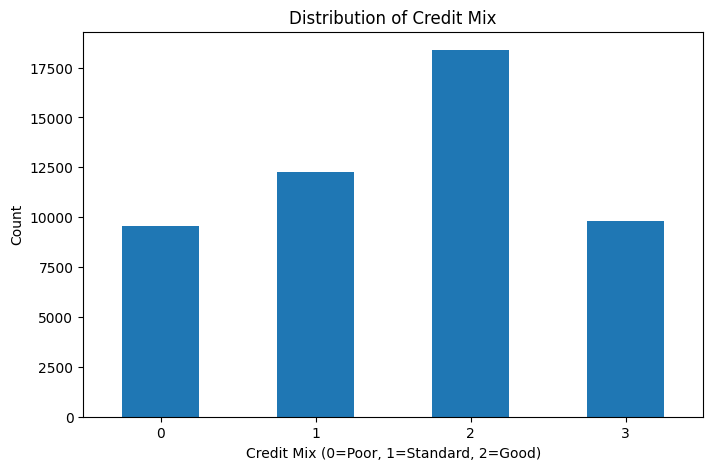

In [14]:
print(df['Credit_Mix'].value_counts().sort_index())
print("\nPercentage:")
print(df['Credit_Mix'].value_counts(normalize=True).sort_index() * 100)


plt.figure(figsize=(8, 5))
df['Credit_Mix'].value_counts().sort_index().plot(kind='bar')
plt.title('Distribution of Credit Mix')
plt.xlabel('Credit Mix (0=Poor, 1=Standard, 2=Good)')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

### Correlation with target only

TOP 15 FEATURES CORRELATED WITH CREDIT MIX
Credit_Mix                                            1.000000
Credit_History_Age                                    0.207288
Monthly_Inhand_Salary                                 0.058615
Annual_Income                                         0.056468
Age                                                   0.038269
Amount_invested_monthly                               0.028645
Payment_Behaviour_High_spent_Large_value_payments     0.022996
Credit_Utilization_Ratio                              0.021859
Occupation_Media_Manager                              0.020775
Payment_of_Min_Amount_No                              0.015667
Payment_Behaviour_High_spent_Medium_value_payments    0.013109
Occupation_Lawyer                                     0.008648
Type_of_Loan                                          0.008580
Occupation_Writer                                     0.008354
Occupation_Journalist                                 0.007129
dtype: float

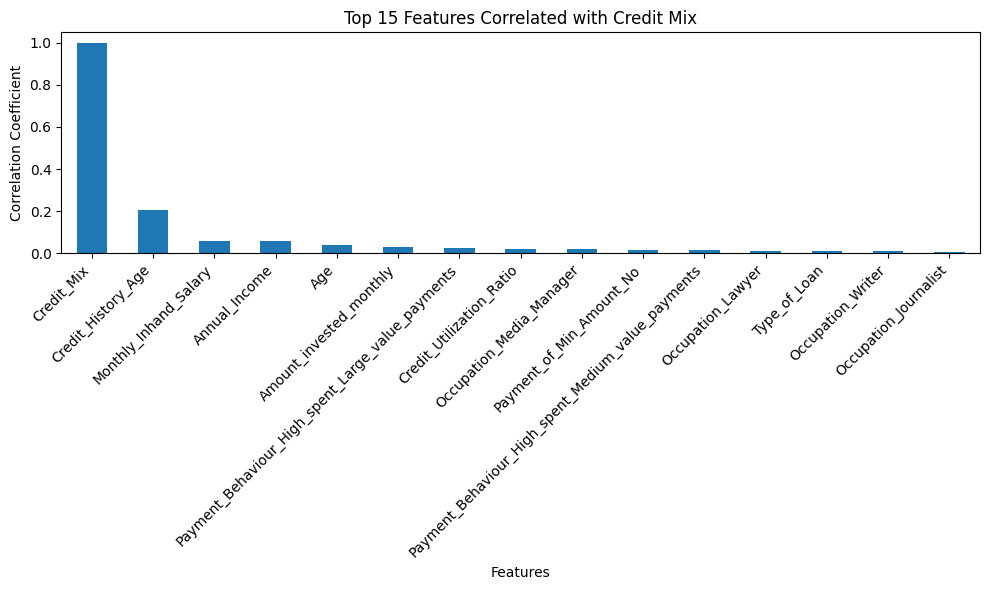

In [15]:
print("TOP 15 FEATURES CORRELATED WITH CREDIT MIX")
correlations = df.corrwith(df['Credit_Mix']).sort_values(ascending=False)
print(correlations.head(15))

plt.figure(figsize=(10, 6))
correlations.head(15).plot(kind='bar')
plt.title('Top 15 Features Correlated with Credit Mix')
plt.xlabel('Features')
plt.ylabel('Correlation Coefficient')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### Box plots for top important features

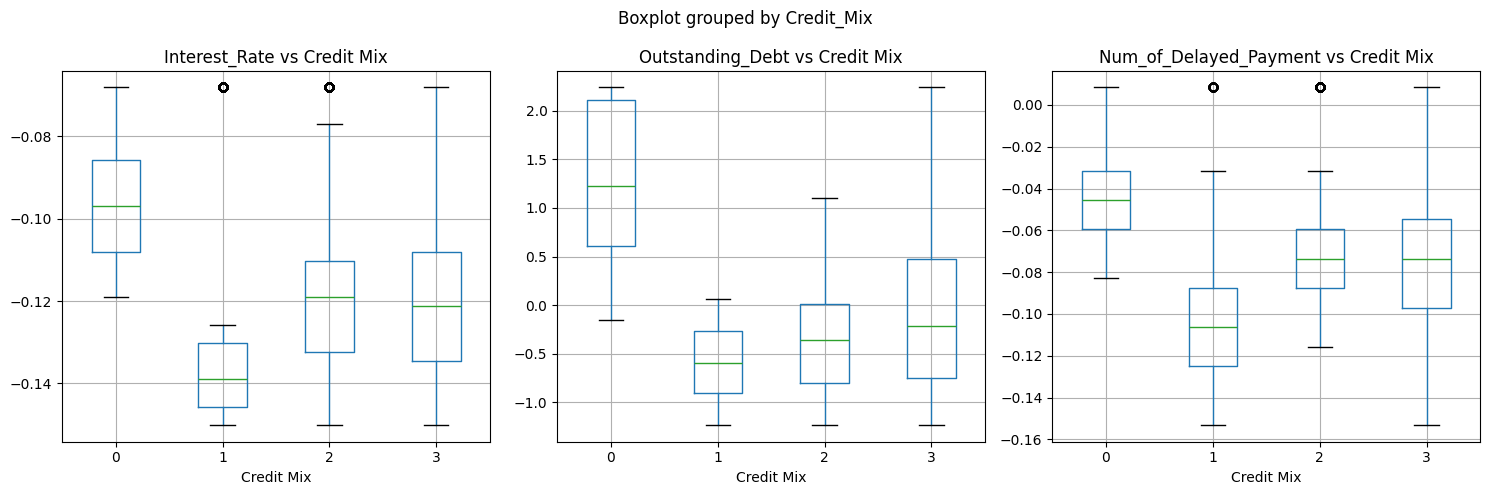

In [16]:
top_features = ['Interest_Rate', 'Outstanding_Debt', 'Num_of_Delayed_Payment']

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for i, feature in enumerate(top_features):
    if feature in df.columns:
        df.boxplot(column=feature, by='Credit_Mix', ax=axes[i])
        axes[i].set_title(f'{feature} vs Credit Mix')
        axes[i].set_xlabel('Credit Mix')
 
plt.tight_layout()
plt.show()



### Check for any anomalies

In [17]:
print("DATA VALIDATION")
print(f"Dataset shape: {df.shape}")
print(f"Missing values: {df.isnull().sum().sum()}")
print(f"Number of features: {df.shape[1]}")
print(f"Number of samples: {df.shape[0]}")

DATA VALIDATION
Dataset shape: (50000, 45)
Missing values: 0
Number of features: 45
Number of samples: 50000


## 3. Model Building
- Train multiple machine learning models using the preprocessed data.
- Evaluate the suitability of various models for the task.


In [18]:
X = df.drop('Credit_Mix', axis=1)
y = df['Credit_Mix']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Train Model 1: Logistic Regression

In [19]:
model1 = LogisticRegression(max_iter=1000)
model1.fit(X_train, y_train)
print("Model 1: Logistic Regression trained successfully!")

Model 1: Logistic Regression trained successfully!


### # Train Model 2: Decision Tree

In [20]:
model2 = DecisionTreeClassifier()
model2.fit(X_train, y_train)
print("Model 2: Decision Tree trained successfully!")

Model 2: Decision Tree trained successfully!


### Train Model 3: Random Forest

In [21]:
model3 = RandomForestClassifier()
model3.fit(X_train, y_train)
print("Model 3: Random Forest trained successfully!")

Model 3: Random Forest trained successfully!


In [22]:

print("WHY THESE MODELS FOR CREDIT MIX PREDICTION?")


print("\n1. LOGISTIC REGRESSION:")
print(" Good baseline model to compare others against")
print(" Fast training on 50,000 samples")
print(" Works if credit factors have linear relationships")

print("\n2. DECISION TREE:")
print(" Captures non-linear patterns in credit behavior")
print(" Easy to understand rules (e.g., 'If delayed payments > 5 → Poor credit')")
print(" No feature scaling needed")

print("\n3. RANDOM FOREST:")
print(" Handles complex interactions between multiple credit factors")
print(" Provides feature importance to identify key factors")
print(" Reduces overfitting by averaging multiple trees")
print(" Most accurate for this type of financial data")
print(" Gives reliable predictions across all credit mix classes")

print(" RANDOM FOREST is best suited for this credit mix task")

WHY THESE MODELS FOR CREDIT MIX PREDICTION?

1. LOGISTIC REGRESSION:
 Good baseline model to compare others against
 Fast training on 50,000 samples
 Works if credit factors have linear relationships

2. DECISION TREE:
 Captures non-linear patterns in credit behavior
 Easy to understand rules (e.g., 'If delayed payments > 5 → Poor credit')
 No feature scaling needed

3. RANDOM FOREST:
 Handles complex interactions between multiple credit factors
 Provides feature importance to identify key factors
 Reduces overfitting by averaging multiple trees
 Most accurate for this type of financial data
 Gives reliable predictions across all credit mix classes
 RANDOM FOREST is best suited for this credit mix task


## 4. Model Evaluation
- Compute and plot evaluation metrics for all models, such as accuracy, precision, recall, F1-score, and AUC-ROC.
- Compare the performance of models across multiple metrics.


### Logistic Regression

In [23]:
y_pred1 = model1.predict(X_test)
acc1 = accuracy_score(y_test, y_pred1)
prec1 = precision_score(y_test, y_pred1, average='weighted')
rec1 = recall_score(y_test, y_pred1, average='weighted')
f11 = f1_score(y_test, y_pred1, average='weighted')

print("="*50)
print("MODEL 1: LOGISTIC REGRESSION")
print("="*50)
print(f"Accuracy: {acc1:.4f}")
print(f"Precision: {prec1:.4f}")
print(f"Recall: {rec1:.4f}")
print(f"F1-Score: {f11:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred1))

MODEL 1: LOGISTIC REGRESSION
Accuracy: 0.6899
Precision: 0.6072
Recall: 0.6899
F1-Score: 0.6315

Confusion Matrix:
[[1687    0  222   11]
 [   0 2284  127   47]
 [ 148  418 2861  228]
 [ 435  643  822   67]]


### Decision Tree

In [24]:
y_pred2 = model2.predict(X_test)
acc2 = accuracy_score(y_test, y_pred2)
prec2 = precision_score(y_test, y_pred2, average='weighted')
rec2 = recall_score(y_test, y_pred2, average='weighted')
f12 = f1_score(y_test, y_pred2, average='weighted')

print("\n" + "="*50)
print("MODEL 2: DECISION TREE")
print("="*50)
print(f"Accuracy: {acc2:.4f}")
print(f"Precision: {prec2:.4f}")
print(f"Recall: {rec2:.4f}")
print(f"F1-Score: {f12:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred2))


MODEL 2: DECISION TREE
Accuracy: 0.6475
Precision: 0.6573
Recall: 0.6475
F1-Score: 0.6522

Confusion Matrix:
[[1447    0   72  401]
 [   0 1881   87  490]
 [  71   91 2694  799]
 [ 346  454  714  453]]


### Random Forest

In [25]:
y_pred3 = model3.predict(X_test)
acc3 = accuracy_score(y_test, y_pred3)
prec3 = precision_score(y_test, y_pred3, average='weighted')
rec3 = recall_score(y_test, y_pred3, average='weighted')
f13 = f1_score(y_test, y_pred3, average='weighted')

print("\n" + "="*50)
print("MODEL 3: RANDOM FOREST")
print("="*50)
print(f"Accuracy: {acc3:.4f}")
print(f"Precision: {prec3:.4f}")
print(f"Recall: {rec3:.4f}")
print(f"F1-Score: {f13:.4f}")
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred3))


MODEL 3: RANDOM FOREST
Accuracy: 0.7703
Precision: 0.6610
Recall: 0.7703
F1-Score: 0.6958

Confusion Matrix:
[[1854    0   32   34]
 [   0 2374   51   33]
 [  45   86 3445   79]
 [ 438  603  896   30]]


## 5. Hyperparameter Tuning
- Optimize hyperparameters for each model using systematic search methods.
- Identify the best configuration for improved performance.


### Logistic Regression Tuning

In [26]:
print("Tuning Logistic Regression...")
param_grid_lr = {
    'C': [0.1, 1.0, 10.0],
    'max_iter': [500, 1000]
}
grid_lr = GridSearchCV(LogisticRegression(), param_grid_lr, cv=3, scoring='accuracy')
grid_lr.fit(X_train, y_train)
print(f"Best parameters: {grid_lr.best_params_}")
print(f"Best CV score: {grid_lr.best_score_:.4f}")

Tuning Logistic Regression...
Best parameters: {'C': 10.0, 'max_iter': 1000}
Best CV score: 0.7019


### Decision Tree Tuning

In [27]:
print("Tuning Decision Tree...")
param_grid_dt = {
    'max_depth': [5, 10, 15, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
grid_dt = GridSearchCV(DecisionTreeClassifier(), param_grid_dt, cv=3, scoring='accuracy')
grid_dt.fit(X_train, y_train)
print(f"Best parameters: {grid_dt.best_params_}")
print(f"Best CV score: {grid_dt.best_score_:.4f}")

Tuning Decision Tree...
Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best CV score: 0.7344


### Random Forest Tuning

In [28]:
print("Tuning Random Forest...")
param_grid_rf = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5]
}
grid_rf = GridSearchCV(RandomForestClassifier(), param_grid_rf, cv=3, scoring='accuracy')
grid_rf.fit(X_train, y_train)
print(f"Best parameters: {grid_rf.best_params_}")
print(f"Best CV score: {grid_rf.best_score_:.4f}")

Tuning Random Forest...
Best parameters: {'max_depth': None, 'min_samples_split': 5, 'n_estimators': 100}
Best CV score: 0.7693


## 6. Retrain Models
- Retrain all models using the optimal hyperparameters on the training data.
- Validate the models on unseen data to ensure robustness.

### Retrain Logistic Regression

In [29]:
print("Retraining Logistic Regression...")
model1_tuned = LogisticRegression(C=grid_lr.best_params_['C'], 
                                   max_iter=grid_lr.best_params_['max_iter'])
model1_tuned.fit(X_train, y_train)
print("Logistic Regression retrained with best parameters")

Retraining Logistic Regression...
Logistic Regression retrained with best parameters


### Retrain Decision Tree

In [30]:
print("Retraining Decision Tree...")
model2_tuned = DecisionTreeClassifier(
    max_depth=grid_dt.best_params_['max_depth'],
    min_samples_split=grid_dt.best_params_['min_samples_split'],
    min_samples_leaf=grid_dt.best_params_['min_samples_leaf']
)
model2_tuned.fit(X_train, y_train)
print("Decision Tree retrained with best parameters")

Retraining Decision Tree...
Decision Tree retrained with best parameters


### Retrain Random Forest

In [31]:
print("\n3. Retraining Random Forest...")
model3_tuned = RandomForestClassifier(
    n_estimators=grid_rf.best_params_['n_estimators'],
    max_depth=grid_rf.best_params_['max_depth'],
    min_samples_split=grid_rf.best_params_['min_samples_split']
)
model3_tuned.fit(X_train, y_train)
print("Random Forest retrained with best parameters")


3. Retraining Random Forest...
Random Forest retrained with best parameters


## 7. Final Performance and Cross-Validation
- Evaluate the final performance of each model using cross-validation scores.
- Compare results to select the best-performing model.


### Final Performance of Each Model using Cross-validation scores

In [32]:
print("="*50)
print("CROSS-VALIDATION RESULTS")
print("="*50)

# Logistic Regression CV
cv_scores1 = cross_val_score(model1_tuned, X_train, y_train, cv=5)
print(f"Logistic Regression - CV Mean: {cv_scores1.mean():.4f} (+/- {cv_scores1.std()*2:.4f})")

# Decision Tree CV
cv_scores2 = cross_val_score(model2_tuned, X_train, y_train, cv=5)
print(f"Decision Tree - CV Mean: {cv_scores2.mean():.4f} (+/- {cv_scores2.std()*2:.4f})")

# Random Forest CV
cv_scores3 = cross_val_score(model3_tuned, X_train, y_train, cv=5)
print(f"Random Forest - CV Mean: {cv_scores3.mean():.4f} (+/- {cv_scores3.std()*2:.4f})")



CROSS-VALIDATION RESULTS
Logistic Regression - CV Mean: 0.7031 (+/- 0.0052)
Decision Tree - CV Mean: 0.7368 (+/- 0.0071)
Random Forest - CV Mean: 0.7707 (+/- 0.0047)


### Final Test Performance

In [33]:
print("\n" + "="*50)
print("FINAL TEST SET PERFORMANCE")
print("="*50)

# Logistic Regression
y_pred1 = model1_tuned.predict(X_test)
print(f"Logistic Regression Test Accuracy: {accuracy_score(y_test, y_pred1):.4f}")

# Decision Tree
y_pred2 = model2_tuned.predict(X_test)
print(f"Decision Tree Test Accuracy: {accuracy_score(y_test, y_pred2):.4f}")

# Random Forest
y_pred3 = model3_tuned.predict(X_test)
print(f"Random Forest Test Accuracy: {accuracy_score(y_test, y_pred3):.4f}")


FINAL TEST SET PERFORMANCE
Logistic Regression Test Accuracy: 0.6982
Decision Tree Test Accuracy: 0.7303
Random Forest Test Accuracy: 0.7719


### After compare Random Forest is the best performing model

## 8. Suggestions
- Provide recommendations based on the model insights and analysis.
- Suggest actionable steps to improve outcomes or address any gaps identified during the project.


### Model insights and analysis

In [34]:
importance = model3_tuned.feature_importances_
feature_names = X.columns

feature_imp = pd.DataFrame({
    'feature': feature_names,
    'importance': importance
}).sort_values('importance', ascending=False)

print("="*60)
print("TOP 5 FACTORS AFFECTING CREDIT MIX:")
print("="*60)
for i in range(5):
    print(f"{i+1}. {feature_imp.iloc[i]['feature']}: {feature_imp.iloc[i]['importance']:.3f}")

TOP 5 FACTORS AFFECTING CREDIT MIX:
1. Interest_Rate: 0.104
2. Outstanding_Debt: 0.089
3. Num_of_Delayed_Payment: 0.088
4. Num_Bank_Accounts: 0.072
5. Delay_from_due_date: 0.070


### Recommendations

In [35]:
print("\n" + "="*60)
print("RECOMMENDATIONS TO IMPROVE CREDIT MIX:")
print("="*60)

print("\n1. To Reduce INTEREST RATE:")
print("Negotiate with banks for lower interest rates")
print("Transfer high-interest debt to lower interest cards")
print("Maintain good credit score to qualify for better rates")

print("\n2. To Manage OUTSTANDING DEBT:")
print("Pay more than minimum amount each month")
print("Focus on paying off highest interest debt first")
print("Create a debt repayment plan")

print("To Reduce DELAYED PAYMENTS:")
print("Set up automatic payments for all bills")
print("Mark payment due dates on calendar")
print("Pay bills immediately after receiving salary")

print("\n4. Regarding PAYMENT OF MINIMUM AMOUNT:")
print("Always pay at least minimum amount before due date")
print("Try to pay full amount to avoid interest charges")
print("Never miss minimum payment - it hurts credit most")

print("Regarding BANK ACCOUNTS:")
print("Maintain 2-3 active bank accounts ideally")
print("Don't open too many accounts at once")
print("Keep oldest accounts open for credit history")

print("\n" + "="*60)
print("Follow these recommendations for next 3-6 months")
print("to see improvement in your credit mix.")


RECOMMENDATIONS TO IMPROVE CREDIT MIX:

1. To Reduce INTEREST RATE:
Negotiate with banks for lower interest rates
Transfer high-interest debt to lower interest cards
Maintain good credit score to qualify for better rates

2. To Manage OUTSTANDING DEBT:
Pay more than minimum amount each month
Focus on paying off highest interest debt first
Create a debt repayment plan
To Reduce DELAYED PAYMENTS:
Set up automatic payments for all bills
Mark payment due dates on calendar
Pay bills immediately after receiving salary

4. Regarding PAYMENT OF MINIMUM AMOUNT:
Always pay at least minimum amount before due date
Try to pay full amount to avoid interest charges
Never miss minimum payment - it hurts credit most
Regarding BANK ACCOUNTS:
Maintain 2-3 active bank accounts ideally
Don't open too many accounts at once
Keep oldest accounts open for credit history

Follow these recommendations for next 3-6 months
to see improvement in your credit mix.
